# EDA for New Occurrence Data

"pt" = Permian-Triassic = Perm_Trias folder

"gl" = Guadilupian-Ladinian = Guad-Ladin folder

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Permian-Triassic Data


## Loading + Filtering + EDA Occs Data

In [32]:
pt_reptilia_all = pd.read_excel("Perm-Trias/occs_combined/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_All_AF_Tiago_combined.xlsx")
pt_reptilia_terr = pd.read_excel("Perm-Trias/occs_combined/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_terres_AF_Tiago_combined.xlsx")
pt_synapsida = pd.read_excel("Perm-Trias/occs_combined/synapsida_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_AF_Tiago_combined.xlsx")

# gl_reptilia = pd.read_excel("Guad-Ladin/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_terres_MidTria.xlsx")
# gl_synapsida = pd.read_excel("Guad-Ladin/synapsida_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_MidTria.xlsx")

In [33]:
pt_reptilia_all.columns

Index(['occurrence_no', 'occurrence_no_AF', 'id', 'id_seperated', 'expt',
       'Rotated latitude', 'Rotated longitude', 'i_index', 'j_index',
       'Topo. (m)',
       ...
       'geoplate', 'paleoage', 'paleolng', 'paleolat', 'paleomodel2',
       'geoplate2', 'paleoage2', 'paleolng2', 'paleolat2', 'paleomodel3'],
      dtype='object', length=296)

In [34]:

pt_reptilia_all_filtered = pt_reptilia_all[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]
pt_reptilia_terr_filtered = pt_reptilia_terr[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]
pt_synapsida_filtered = pt_synapsida[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]

# Need to add 'id' back in
# gl_reptilia_filtered = gl_reptilia[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min']]
# gl_synapsida_filtered = gl_synapsida[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min']]

In [35]:
list_filtered_dfs = [pt_reptilia_all_filtered, pt_reptilia_terr_filtered, pt_synapsida_filtered]
                        # ,gl_reptilia_filtered, gl_synapsida_filtered]

list_filtered_dfs_names = ['pt_reptilia_all_filtered', 'pt_reptilia_terr_filtered', 'pt_synapsida_filtered']
                        # ,'gl_reptilia_filtered', 'gl_synapsida_filtered']

# write a loop for 0:len(list_filtered_dfs) to print the name of each dataframe and its description
# and the number of missing values in each column
for i in range(len(list_filtered_dfs)):
    print(f"DataFrame: {list_filtered_dfs_names[i]}")
    print(list_filtered_dfs[i].describe())
    print(list_filtered_dfs[i].isna().sum())
    # Check that occurrence_no_AF is the same as occurrence_no, because the former came from Alex's dataset and the latter from Tiago's dataset.
    # If they're the same we know merging the two datasets happened correctly.
    different_rows = list_filtered_dfs[i].loc[list_filtered_dfs[i]['occurrence_no'] != list_filtered_dfs[i]['occurrence_no_AF']]
    length_different_rows = different_rows.shape[0]
    print(f"Number of rows where 'occurrence_no' and 'occurrence_no_AF' are different: {length_different_rows}")


DataFrame: pt_reptilia_all_filtered
               id  Rotated latitude      age_max      age_min
count  3987.00000       3987.000000  3987.000000  3987.000000
mean   5134.00000        -71.255378   244.115497   234.918219
std    1151.09209        820.651838    22.017241    24.675819
min    3141.00000      -9999.000000   201.400000   199.500000
25%    4137.50000        -47.039270   227.000000   208.500000
50%    5134.00000          1.353064   242.000000   237.000000
75%    6130.50000         27.011270   259.510000   251.902000
max    7127.00000         61.323520   298.900000   293.520000
id                  0
occurrence_no       0
occurrence_no_AF    0
Rotated latitude    0
genus               0
age_max             0
age_min             0
Epoch               0
dtype: int64
Number of rows where 'occurrence_no' and 'occurrence_no_AF' are different: 0
DataFrame: pt_reptilia_terr_filtered
                id  Rotated latitude      age_max      age_min
count  3140.000000       3140.000000  31

## Ages Visualization (Range Plots)

In [36]:
# Custom function to plot age RANGE (x) frequency (y) with log scale
def range_plot(df, df_name, age_max_col='age_max', age_min_col='age_min'):
    # # Count the frequency of each age range
    # df['range'] = df.apply(lambda row: (row['age_max'], row['age_min']), axis=1)
    # frequency = df['range'].value_counts().sort_index()
    
    # Count the frequency of each age range
    df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)
    frequency = df['range'].value_counts().sort_index()
    # Create the plot
    fig, ax = plt.subplots(figsize=(12,6))

    # Plot each range as a horizontal line with log-transformed y-values
    for (age_min, age_max), count in frequency.items():
        ax.plot([age_min, age_max], [np.log(count)] * 2, 'b-', linewidth=2)

    # Set the axis labels and title
    ax.set_xlabel('Age')
    ax.set_ylabel('Log(Frequency)')
    ax.set_title(f'{df_name} Age Range Frequency Plot (Log Scale)')

    # Get the x-axis limits
    x_min, x_max = ax.get_xlim()

    # Create ticks for every 1 unit
    ticks = np.arange(np.ceil(x_min), np.floor(x_max) + 1, 1)
    ax.set_xticks(ticks)

    # Create labels for every 5 units
    labels = [str(int(x)) if x % 5 == 0 else '' for x in ticks]
    ax.set_xticklabels(labels)

    # Invert the x-axis
    ax.invert_xaxis()

    # Add horizontal line at y=log(10)
    ax.axhline(y=np.log(10), color='r', linestyle='--', linewidth=2)

    # Customize y-axis ticks to show original frequency values
    y_ticks = ax.get_yticks()
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{np.exp(y):.0f}' for y in y_ticks])

    # Add vertical lines at the time-bin x-values
    vertical_lines = [290.1, 283.5, 273, 264.3, 259.5, 252, 247, 242, 237, 227, 217, 208]
    for vline in vertical_lines:
        ax.axvline(x=vline, color='g', linestyle='--', linewidth=1)

    # Show the plot
    plt.tight_layout()
    plt.show()
    plt.close()

    return fig

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_19484\2271861712.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


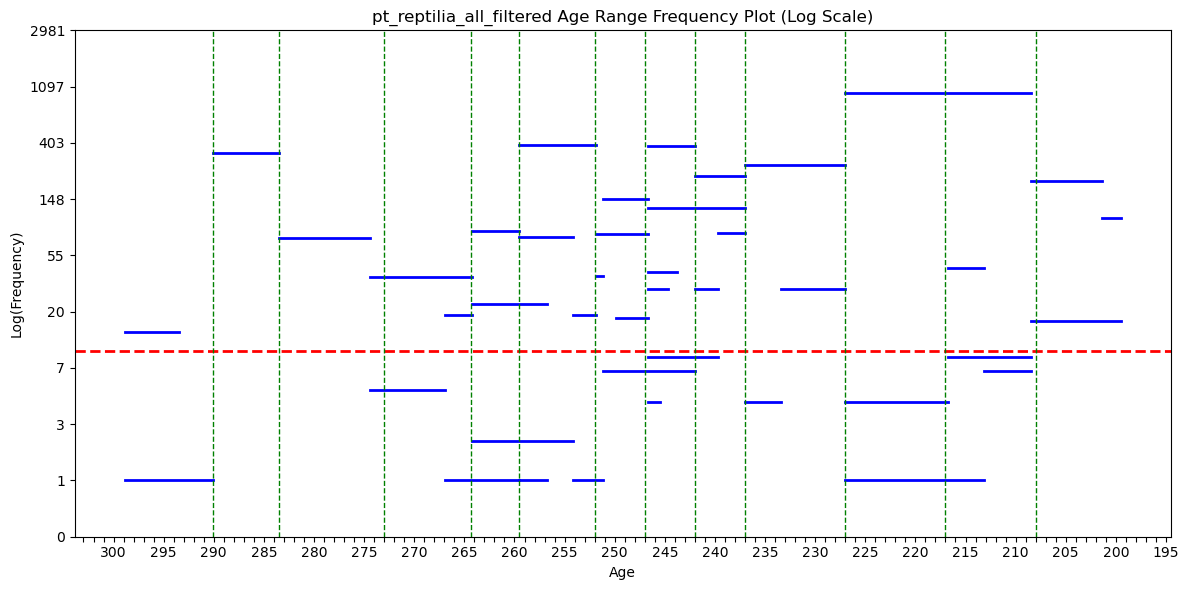

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_19484\2271861712.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


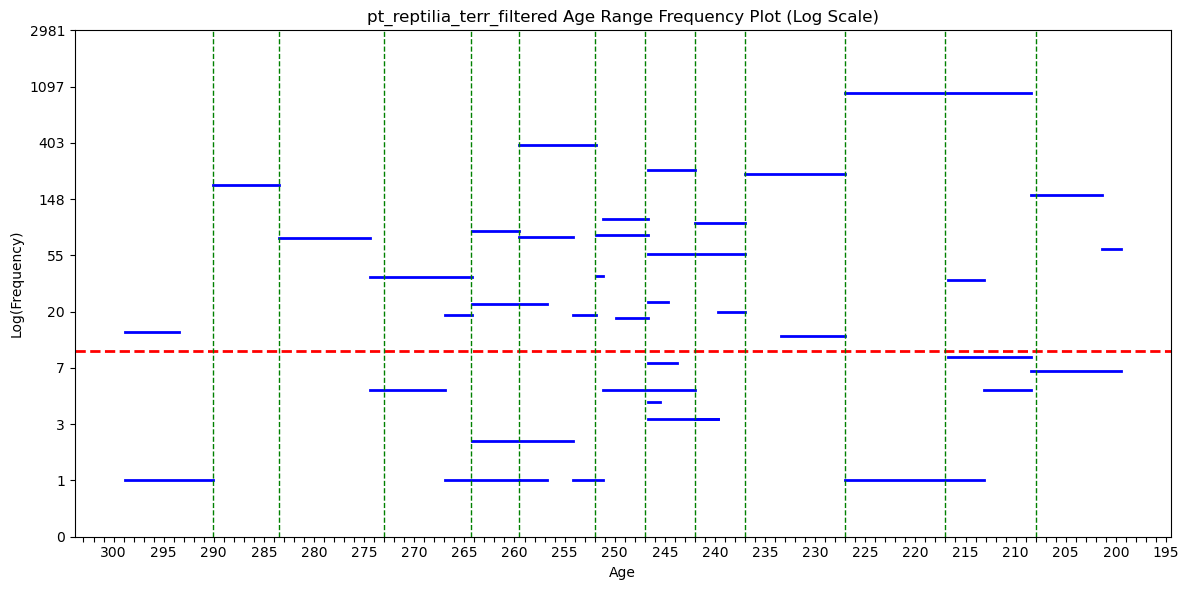

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_19484\2271861712.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


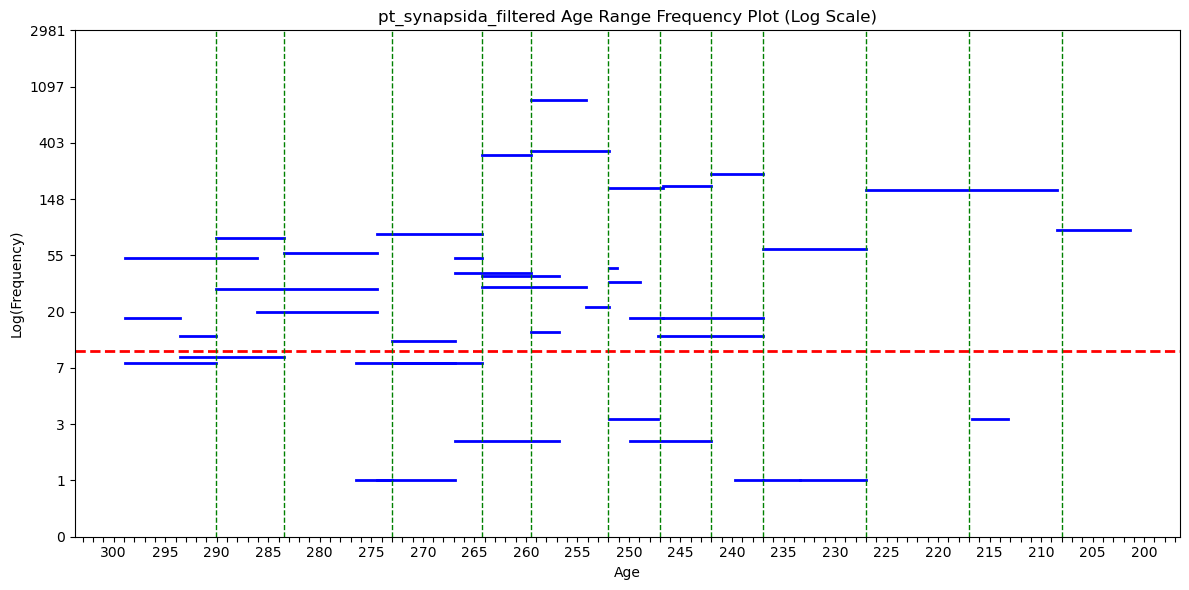

In [38]:
# plot each dataframe using the custom function
# then save the figures

for i in range(len(list_filtered_dfs)):
    fig = range_plot(list_filtered_dfs[i], list_filtered_dfs_names[i])
    fig.savefig(f"Perm-Trias/pt_data_visualizations/{list_filtered_dfs_names[i]}_age_range_frequency_plot.png")


## Dropping non-letter 'genus' strings

In [39]:
# See if there are any non-letters in the 'genus' columns of each dataframe
for i in range(len(list_filtered_dfs)):
    non_letters = list_filtered_dfs[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names[i]}")
        print(f"Non-letter characters found in 'genus': {list_filtered_dfs[i][non_letters]['genus'].unique()}\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered
Non-letter characters found in 'genus': ['new Neotheropoda' 'new Rhynchocephalia' 'Stenoscelida\xa0']

DataFrame: pt_reptilia_terr_filtered
Non-letter characters found in 'genus': ['new Neotheropoda' 'new Rhynchocephalia' 'Stenoscelida\xa0']

DataFrame: pt_synapsida_filtered
Non-letter characters found in 'genus': ['-' 'Bonacynodon ']



In [40]:
# print the rows with non-letter characters in the 'genus' column
for i in range(len(list_filtered_dfs)):
    non_letters = list_filtered_dfs[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names[i]}")
        print(list_filtered_dfs[i][non_letters])
        print("\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered
       id occurrence_no occurrence_no_AF  Rotated latitude  \
974  4115          N363             N363         -46.11636   
975  4116          N364             N364         -46.11636   
979  4120          N503             N503         -46.11636   

                   genus  age_max  age_min           Epoch           range  
974     new Neotheropoda    227.0    208.5  Upper Triassic  (227.0, 208.5)  
975  new Rhynchocephalia    227.0    208.5  Upper Triassic  (227.0, 208.5)  
979        Stenoscelida     227.0    208.5  Upper Triassic  (227.0, 208.5)  


DataFrame: pt_reptilia_terr_filtered
      id occurrence_no occurrence_no_AF  Rotated latitude  \
968  969          N363             N363         -46.11636   
969  970          N364             N364         -46.11636   
973  974          N503             N503         -46.11636   

                   genus  age_max  age_min           Epoch           range  
968     new Neotheropoda    227.0    208.5  Up

In [41]:
# Fixing those

# Make a copy of the filtered dataframes to avoid modifying the original ones
pt_reptilia_all_filtered_spellchecked = pt_reptilia_all_filtered.copy()
pt_reptilia_terr_filtered_spellchecked = pt_reptilia_terr_filtered.copy()
pt_synapsida_filtered_spellchecked = pt_synapsida_filtered.copy()

# Now perform all the cleaning

# Strip the ending space from row with index 979 in pt_reptilia_all_filtered in 'genus' column
pt_reptilia_all_filtered_spellchecked.at[979, 'genus'] = pt_reptilia_all_filtered_spellchecked.at[979, 'genus'].strip()

# Strip the ending space from row with index 973 in pt_reptilia_terr_filtered in 'genus' column
pt_reptilia_terr_filtered_spellchecked.at[973, 'genus'] = pt_reptilia_terr_filtered_spellchecked.at[973, 'genus'].strip()

# Strip the ending space from row with index 2685 and 2686 in pt_synapsida_filtered in 'genus' column
pt_synapsida_filtered_spellchecked.at[2685, 'genus'] = pt_synapsida_filtered_spellchecked.at[2685, 'genus'].strip()
pt_synapsida_filtered_spellchecked.at[2686, 'genus'] = pt_synapsida_filtered_spellchecked.at[2686, 'genus'].strip()

# Delete row with index 370 from pt_synapsida_all_filtered
pt_synapsida_filtered_spellchecked = pt_synapsida_filtered_spellchecked.drop(370)



In [42]:
# Check again

list_filtered_dfs_spellchecked = [pt_reptilia_all_filtered_spellchecked, pt_reptilia_terr_filtered_spellchecked, pt_synapsida_filtered_spellchecked]
list_filtered_dfs_names_spellchecked = ['pt_reptilia_all_filtered_spellchecked', 'pt_reptilia_terr_filtered_spellchecked', 'pt_synapsida_filtered_spellchecked']

# print the rows with non-letter characters in the 'genus' column
for i in range(len(list_filtered_dfs_spellchecked)):
    non_letters = list_filtered_dfs_spellchecked[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names_spellchecked[i]}")
        print(list_filtered_dfs_spellchecked[i][non_letters])
        print("\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names_spellchecked[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered_spellchecked
       id occurrence_no occurrence_no_AF  Rotated latitude  \
974  4115          N363             N363         -46.11636   
975  4116          N364             N364         -46.11636   

                   genus  age_max  age_min           Epoch           range  
974     new Neotheropoda    227.0    208.5  Upper Triassic  (227.0, 208.5)  
975  new Rhynchocephalia    227.0    208.5  Upper Triassic  (227.0, 208.5)  


DataFrame: pt_reptilia_terr_filtered_spellchecked
      id occurrence_no occurrence_no_AF  Rotated latitude  \
968  969          N363             N363         -46.11636   
969  970          N364             N364         -46.11636   

                   genus  age_max  age_min           Epoch           range  
968     new Neotheropoda    227.0    208.5  Upper Triassic  (227.0, 208.5)  
969  new Rhynchocephalia    227.0    208.5  Upper Triassic  (227.0, 208.5)  


DataFrame: pt_synapsida_filtered_spellchecked - No non-letter ch

## PT Latitude -9999 Cleaning


In [43]:
pt_reptilia_all_filtered_spellchecked_lats = pt_reptilia_all_filtered_spellchecked.copy()
pt_reptilia_terr_filtered_spellchecked_lats = pt_reptilia_terr_filtered_spellchecked.copy()
pt_synapsida_filtered_spellchecked_lats = pt_synapsida_filtered_spellchecked.copy()


In [44]:
# Checking for nonsense values in the 'Rotated latitude' column
pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'].describe(), pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'].describe(), pt_synapsida_filtered_spellchecked_lats['Rotated latitude'].describe()

(count    3987.000000
 mean      -71.255378
 std       820.651838
 min     -9999.000000
 25%       -47.039270
 50%         1.353064
 75%        27.011270
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3140.000000
 mean      -23.135116
 std       400.134800
 min     -9999.000000
 25%       -49.043510
 50%         1.353064
 75%        24.956070
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3184.000000
 mean      -45.700334
 std       308.060852
 min     -9999.000000
 25%       -61.365010
 50%       -52.001180
 75%       -15.491353
 max        62.825230
 Name: Rotated latitude, dtype: float64)

### Latitude Visualizations

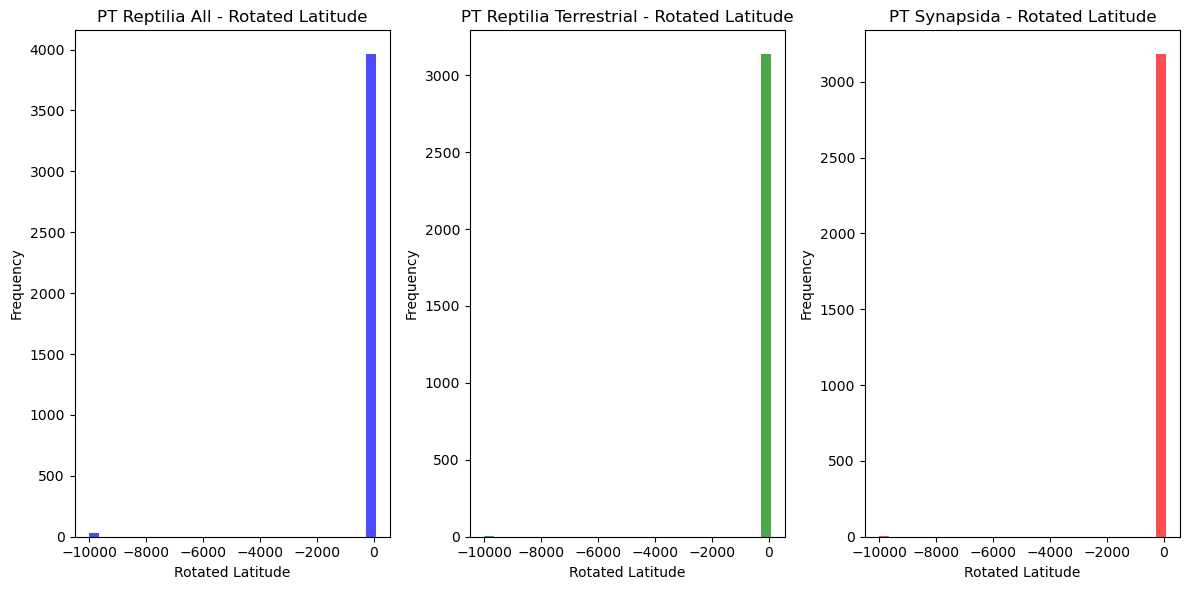

In [45]:
# Visualizing the latitudes
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('PT Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)    
plt.hist(pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='green', alpha=0.7)
plt.title('PT Reptilia Terrestrial - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
plt.hist(pt_synapsida_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('PT Synapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Perm-Trias/pt_data_visualizations/raw_rotated_latitude_histograms.png')
plt.show()

In [55]:
# Viewing the rows whose latitudes are = -9999

pt_reptilia_9999_lats = pt_reptilia_all_filtered_spellchecked_lats[pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'] == -9999]
pt_reptilia_terr_9999_lats = pt_reptilia_terr_filtered_spellchecked_lats[pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'] == -9999]
pt_synapsida_9999_lats = pt_synapsida_filtered_spellchecked_lats[pt_synapsida_filtered_spellchecked_lats['Rotated latitude'] == -9999]

print("Rows with 'Rotated latitude' = -9999 in pt_reptilia_all_filtered_spellchecked_lats:")
print(pt_reptilia_9999_lats)
print("\nRows with 'Rotated latitude' = -9999 in pt_reptilia_terr_filtered_spellchecked_lats:")
print(pt_reptilia_terr_9999_lats)
print("\nRows with 'Rotated latitude' = -9999 in pt_synapsida_filtered_spellchecked_lats:")
print(pt_synapsida_9999_lats)


Rows with 'Rotated latitude' = -9999 in pt_reptilia_all_filtered_spellchecked_lats:
        id occurrence_no occurrence_no_AF  Rotated latitude            genus  \
691   3832       1108583          1108583           -9999.0     Shastasaurus   
1068  4209        337694           337694           -9999.0   Neusticosaurus   
1069  4210        337705           337705           -9999.0     Cymatosaurus   
1340  4481       1134408          1134408           -9999.0  Californosaurus   
1346  4487       1181747          1181747           -9999.0      Nectosaurus   
1347  4488       1181748          1181748           -9999.0      Nectosaurus   
1348  4489       1181749          1181749           -9999.0     Shastasaurus   
1349  4490       1181750          1181750           -9999.0   Thalattosaurus   
1368  4509       1388419          1388419           -9999.0      Nectosaurus   
1383  4524       1419468          1419468           -9999.0     Shastasaurus   
1384  4525       1419470          14

In [47]:
# After checking with Tiago, we decided to drop the rows with 'Rotated latitude' = -9999
pt_reptilia_all_filtered_spellchecked_lats_dropped = pt_reptilia_all_filtered_spellchecked_lats[pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'] != -9999]
pt_reptilia_terr_filtered_spellchecked_lats_dropped = pt_reptilia_terr_filtered_spellchecked_lats[pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'] != -9999]
pt_synapsida_filtered_spellchecked_lats_dropped = pt_synapsida_filtered_spellchecked_lats[pt_synapsida_filtered_spellchecked_lats['Rotated latitude'] != -9999]

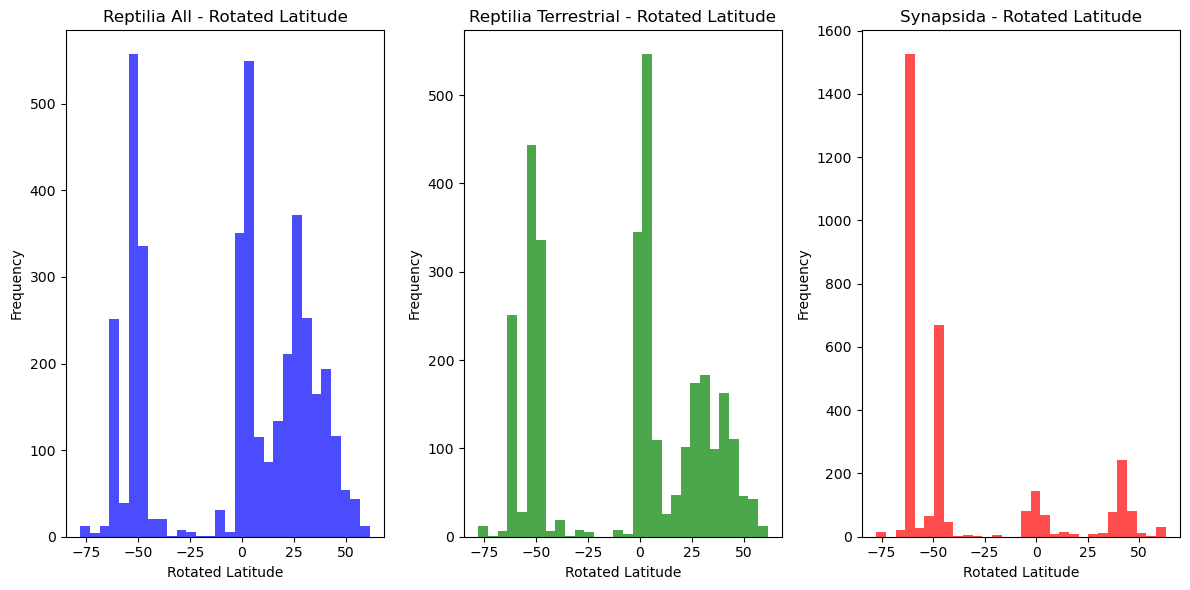

In [49]:
# Visualizing the latitudes now, after having dropped the -9999 values
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(pt_reptilia_all_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)    
plt.hist(pt_reptilia_terr_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='green', alpha=0.7)
plt.title('Reptilia Terrestrial - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
plt.hist(pt_synapsida_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('Synapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Perm-Trias/pt_data_visualizations/cleaned_rotated_latitude_histograms.png')
plt.show()

In [75]:
pt_reptilia_all_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_reptilia_terr_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_synapsida_filtered_spellchecked_lats_dropped['Rotated latitude'].describe()

(count    3960.000000
 mean       -3.566211
 std        36.179317
 min       -77.584400
 25%       -46.558590
 50%         1.357201
 75%        27.011270
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3135.000000
 mean       -7.224646
 std        36.588580
 min       -77.584400
 25%       -49.043510
 50%         1.353064
 75%        24.956070
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3181.000000
 mean      -36.313380
 std        37.978068
 min       -77.584400
 25%       -61.365010
 50%       -52.001180
 75%        -2.980824
 max        62.825230
 Name: Rotated latitude, dtype: float64)

In [51]:
# Save the cleaned dataframes to new csv files
pt_reptilia_all_filtered_spellchecked_lats_dropped.to_csv("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv", index=False)
pt_reptilia_terr_filtered_spellchecked_lats_dropped.to_csv("Perm-Trias/occs_combined/pt_reptilia_terr_cleaned.csv", index=False)
pt_synapsida_filtered_spellchecked_lats_dropped.to_csv("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv", index=False)

## Saving PT Occs off as PyRate Input .txts

Saving off data frames up until now, b/c all the rows that need to be dropped have been dropped

In [ ]:
# If you want to read it in instead of running all above again, uncomment the following lines:
# pt_reptilia_all_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv")
# pt_reptilia_terr_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_terr_cleaned.csv")
# pt_synapsida_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv")

In [52]:
cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

pt_reptilia_all_pyrate_input_txt = pt_reptilia_all_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_reptilia_all_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_reptilia_all_pyrate_input_txt = pt_reptilia_all_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]



pt_reptilia_terr_pyrate_input_txt = pt_reptilia_terr_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_reptilia_terr_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_reptilia_terr_pyrate_input_txt = pt_reptilia_terr_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]



pt_synapsida_pyrate_input_txt = pt_synapsida_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_synapsida_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_synapsida_pyrate_input_txt = pt_synapsida_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]

In [58]:
# Checking that new dataframes are == to the original - the number of rows that had -9999 lats (rows that were dropped)
pt_reptilia_all_filtered.shape[0] - len(pt_reptilia_9999_lats) == pt_reptilia_all_pyrate_input_txt.shape[0], pt_reptilia_terr_filtered.shape[0] - len(pt_reptilia_terr_9999_lats) == pt_reptilia_terr_pyrate_input_txt.shape[0]


(True, True)

In [59]:
# Synapsida dataset should be = original - the number of rows that had -9999 lats (rows that were dropped) 
# - 1 row that was dropped for having no value in 'genus

pt_synapsida_filtered.shape[0], len(pt_synapsida_9999_lats), pt_synapsida_pyrate_input_txt.shape[0]

(3185, 3, 3181)

In [60]:
pt_reptilia_all_pyrate_input_txt.isna().sum(), pt_reptilia_terr_pyrate_input_txt.isna().sum(), pt_synapsida_pyrate_input_txt.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [61]:
pt_reptilia_all_pyrate_input_txt.head(), pt_reptilia_terr_pyrate_input_txt.head(), pt_synapsida_pyrate_input_txt.head()

(          Species   Status  min_age  max_age
 0     Icarosaurus  extinct    208.5    227.0
 1        Rutiodon  extinct    208.5    227.0
 2  Trilophosaurus  extinct    208.5    227.0
 3     Postosuchus  extinct    208.5    227.0
 4     Postosuchus  extinct    208.5    227.0,
       Species   Status  min_age  max_age
 0  Vancleavea  extinct    208.5    227.0
 1  Vancleavea  extinct    208.5    227.0
 2  Vancleavea  extinct    208.5    227.0
 3  Vancleavea  extinct    208.5    227.0
 4  Vancleavea  extinct    208.5    227.0,
         Species   Status  min_age  max_age
 0    Dimetrodon  extinct    286.1    298.9
 1    Ophiacodon  extinct    286.1    298.9
 2   Sphenacodon  extinct    286.1    298.9
 3  Edaphosaurus  extinct    286.1    298.9
 4    Ophiacodon  extinct    286.1    298.9)

In [62]:
# Check data types
print(pt_reptilia_all_pyrate_input_txt.dtypes)
print(pt_reptilia_terr_pyrate_input_txt.dtypes)
print(pt_synapsida_pyrate_input_txt.dtypes)

Species     object
Status      object
min_age    float64
max_age    float64
dtype: object
Species     object
Status      object
min_age    float64
max_age    float64
dtype: object
Species     object
Status      object
min_age    float64
max_age    float64
dtype: object


In [63]:
# Check if min_age is ever greater than max_age
print("Checking if min_age is ever greater than max_age in pt_reptilia_all_pyrate_input_txt:")
print((pt_reptilia_all_pyrate_input_txt['min_age'] > pt_reptilia_all_pyrate_input_txt['max_age']).any())
print("Checking if min_age is ever greater than max_age in pt_reptilia_terr_pyrate_input_txt:")
print((pt_reptilia_terr_pyrate_input_txt['min_age'] > pt_reptilia_terr_pyrate_input_txt['max_age']).any())
print("Checking if min_age is ever greater than max_age in pt_synapsida_pyrate_input_txt:")
print((pt_synapsida_pyrate_input_txt['min_age'] > pt_synapsida_pyrate_input_txt['max_age']).any())


Checking if min_age is ever greater than max_age in pt_reptilia_all_pyrate_input_txt:
False
Checking if min_age is ever greater than max_age in pt_reptilia_terr_pyrate_input_txt:
False
Checking if min_age is ever greater than max_age in pt_synapsida_pyrate_input_txt:
False


In [64]:
# Saving all off as .txt's
pt_reptilia_all_pyrate_input_txt.to_csv("Perm-Trias/pt_reptilia_all_pyrate_input_txt.txt", sep="\t", index=False)
pt_reptilia_terr_pyrate_input_txt.to_csv("Perm-Trias/pt_reptilia_terr_pyrate_input_txt.txt", sep="\t", index=False)
pt_synapsida_pyrate_input_txt.to_csv("Perm-Trias/pt_synapsida_pyrate_input_txt.txt", sep="\t", index=False)


## DEFUNCT: PT Latitude Binning ("New" Genera)

### UPDATE: We've decided on a different method of taking into account wide-ranging species with large latitudinal ranges. See the sections on creating the BDNN trait file. HOWEVER, there is a **LATITUDINAL RANGE VISUALIZATION** in this section that is useful. Saved off in the pt_data_visuzliations section


I need species-specific trait files, one value per species. However, latitude can range widely within one species, which means averaging latitudes into one value for one species misrepresents the actual geographic distribution of that species. 

I'll need to check the range of latitudes per species, then for species that have a lot of variance in latitudes, I will separate that species into artificial "new" species delineated based off of its latitudinal range, which we have chosen to be 20 degrees

Previous runs done in the "old_occurrence_analyses" folder used the following geological latitude bins:

Latitudinal Bins:
- Arctic Circle: 66 deg 33 mins
- Tropic of Cancer: 23 deg 26 mins
- equator: 0
- Tropic of Capricorn: -23 deg 36 min
- Antarctic Circle: -66 deg 33 min


If 'Rotated Lat' 
- is >66 = Arctic 
- <= 66 & > 23 = Temperate_N
- <= 23 & >= -23 = Tropics
- < -23 & <= -66 = Temperate_S
- < -66 = Antarctic


However, using these lat ranges, there will still be genera whose lat ranges are significantly large (>40 degrees), which still means reducing latitude data to a very coarse resolution, obscuring the effect of latitude as a predictor. 

Below I explore different methods of latitude binning

In [68]:
# If you want to read it in instead of running all above again, uncomment the following lines:
# pt_reptilia_all_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_all_cleaned.csv")
# pt_reptilia_terr_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_combined/pt_reptilia_terr_cleaned.csv")
# pt_synapsida_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_combined/pt_synapsida_cleaned.csv")

In [69]:
pt_reptilia_all_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_reptilia_terr_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_synapsida_filtered_spellchecked_lats_dropped['Rotated latitude'].describe()

(count    3960.000000
 mean       -3.566211
 std        36.179317
 min       -77.584400
 25%       -46.558590
 50%         1.357201
 75%        27.011270
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3135.000000
 mean       -7.224646
 std        36.588580
 min       -77.584400
 25%       -49.043510
 50%         1.353064
 75%        24.956070
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3181.000000
 mean      -36.313380
 std        37.978068
 min       -77.584400
 25%       -61.365010
 50%       -52.001180
 75%        -2.980824
 max        62.825230
 Name: Rotated latitude, dtype: float64)

In all clades/datasets, "Rotated latitude" values span from a minimum of -77.584400 to a maximum of 62.825230

In [73]:
62.825230 - -77.584400

140.40963

In [81]:
# Checking latitudinal ranges
# Group by genus, then calculate the min, max, and range of latitudes

def check_latitudinal_ranges(df, name):
    lat_ranges = df.groupby('genus')['Rotated latitude'].agg(['min', 'max'])
    lat_ranges['range'] = lat_ranges['max'] - lat_ranges['min']
    print(f"Latitudinal ranges for {name}:")
    print(lat_ranges.sort_values(by='range', ascending=False))
    print("\n")
    print("Stats for latitudinal ranges:")
    print(lat_ranges.describe())
    return lat_ranges  

pt_reptilia_all_lat_ranges = check_latitudinal_ranges(pt_reptilia_all_filtered_spellchecked_lats_dropped, 'pt_reptilia_all')
pt_reptilia_terr_lat_ranges = check_latitudinal_ranges(pt_reptilia_terr_filtered_spellchecked_lats_dropped, 'pt_reptilia_terr')
pt_synapsida_lat_ranges = check_latitudinal_ranges(pt_synapsida_filtered_spellchecked_lats_dropped, 'pt_synapsida')


Latitudinal ranges for pt_reptilia_all:
                          min        max       range
genus                                               
Proterosuchus       -62.64909  61.217590  123.866680
Plateosaurus        -65.49458  45.574810  111.069390
Garjainia           -60.68525  48.313280  108.998530
Clevosaurus         -49.47713  52.141190  101.618320
Palacrodon          -77.58440   1.353064   78.937464
...                       ...        ...         ...
Honghesaurus         12.57983  12.579830    0.000000
Hispaniasaurus       10.40624  10.406240    0.000000
Himalayasaurus      -20.44913 -20.449130    0.000000
Heteropelta          26.05520  26.055200    0.000000
new Rhynchocephalia -46.11636 -46.116360    0.000000

[682 rows x 3 columns]


Stats for latitudinal ranges:
              min         max       range
count  682.000000  682.000000  682.000000
mean    -0.589981    3.884420    4.474401
std     36.624130   36.989144   13.293794
min    -77.584400  -76.624660    0.000000
25%  

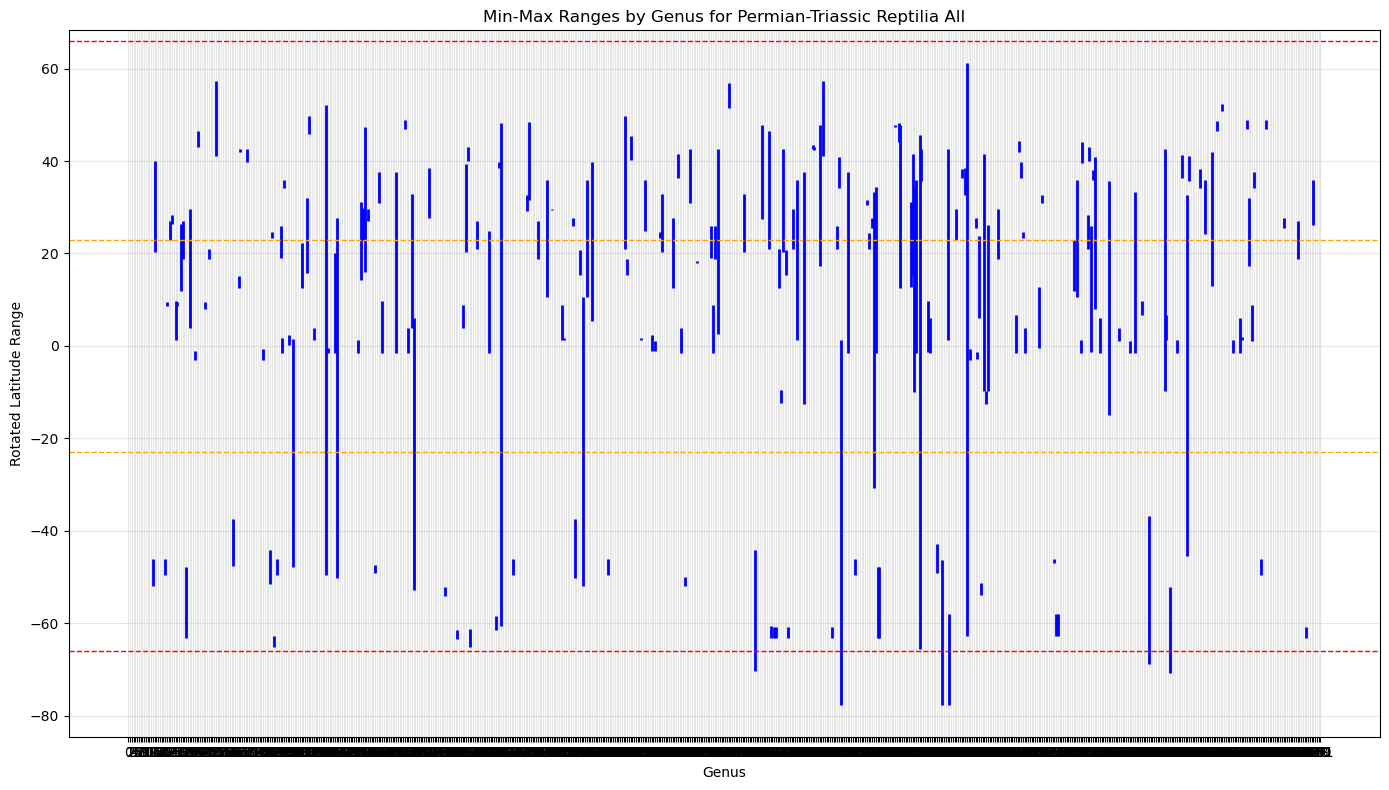

In [ ]:
def plot_genus_ranges_vlines(df, df_name):
    """Plot vertical lines using matplotlib's vlines function"""
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Get x positions (0, 1, 2, ... for each genus)
    x_positions = range(len(df))
    
    # Plot vertical lines from min to max for each genus
    for i, (genus, row) in enumerate(df.iterrows()):
        ax.vlines(x=i, ymin=row['min'], ymax=row['max'], 
                 colors='blue', linewidth=2)
    
    # Set x-axis labels to genus names
    ax.set_xticks(x_positions)
    # ax.set_xticklabels(df.index, rotation=45, ha='right')

    # Set horizontal lines at y = 66, y = 23, y = -23. y = -66
    ax.axhline(y=66, color='red', linestyle='--', linewidth=1)
    ax.axhline(y=23, color='orange', linestyle='--', linewidth=1)
    ax.axhline(y=-23, color='orange', linestyle='--', linewidth=1)
    ax.axhline(y=-66, color='red', linestyle='--', linewidth=1)
    
    # Labels and title
    ax.set_xlabel('Genus')
    ax.set_ylabel('Rotated Latitude Range')
    ax.set_title(f'Min-Max Ranges by Genus for {df_name}')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"Perm-Trias/pt_data_visualizations/{df_name}_lat_ranges_vlines.png", dpi=500)
    plt.show()

plot_genus_ranges_vlines(pt_reptilia_all_lat_ranges, 'Permian-Triassic Reptilia All')
plot_genus_ranges_vlines(pt_reptilia_terr_lat_ranges, 'Permian-Triassic Reptilia Terrestrial')
plot_genus_ranges_vlines(pt_synapsida_lat_ranges, 'Permian-Triassic Synapsida')




In [79]:
pt_reptilia_all_lat_ranges['range'].describe(), pt_reptilia_terr_lat_ranges['range'].describe(), pt_synapsida_lat_ranges['range'].describe()

(count    682.000000
 mean       4.474401
 std       13.293794
 min        0.000000
 25%        0.000000
 50%        0.000000
 75%        2.191812
 max      123.866680
 Name: range, dtype: float64,
 count    555.000000
 mean       4.036313
 std       13.522209
 min        0.000000
 25%        0.000000
 50%        0.000000
 75%        1.708547
 max      123.866680
 Name: range, dtype: float64,
 count    461.000000
 mean       4.733017
 std       15.930623
 min        0.000000
 25%        0.000000
 50%        0.000000
 75%        2.308690
 max      138.801990
 Name: range, dtype: float64)

Trying to ID outliers that might need lat binning via the 1.5IQR rule, for pt_reptilia_all (as a case study). Discovered that using that rule there are a ton more "outliers" than the arbitrary 20 degree lat range we used earlier

In [105]:
series = pt_reptilia_all_lat_ranges['range']
q1 = series.quantile(0.25)
q3 = series.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_pt_reptilia_all_lat_ranges = series[(series < lower_bound) | (series > upper_bound)]
outliers_pt_reptilia_all_lat_ranges.sort_values(ascending=False)

genus
Proterosuchus       123.866680
Plateosaurus        111.069390
Garjainia           108.998530
Clevosaurus         101.618320
Palacrodon           78.937464
                       ...    
Protanystropheus      6.580790
Prestosuchus          6.239960
Eusaurosphargis       6.130070
Aetosauroides         5.884820
Proterochersis        5.796720
Name: range, Length: 106, dtype: float64

In [ ]:
pt_reptilia_all_filtered_spellchecked_lats_dropped[pt_reptilia_all_filtered_spellchecked_lats_dropped['genus'] == 'Proterochersis']

,id,occurrence_no,occurrence_no_AF,Rotated latitude,genus,age_max,age_min,Epoch,range
676,3817,1099834,1099834,34.47747,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
677,3818,1099923,1099923,32.59323,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
678,3819,1099924,1099924,34.47747,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
709,3850,1334449,1334449,34.47747,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
787,3928,1554602,1554602,38.38995,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"


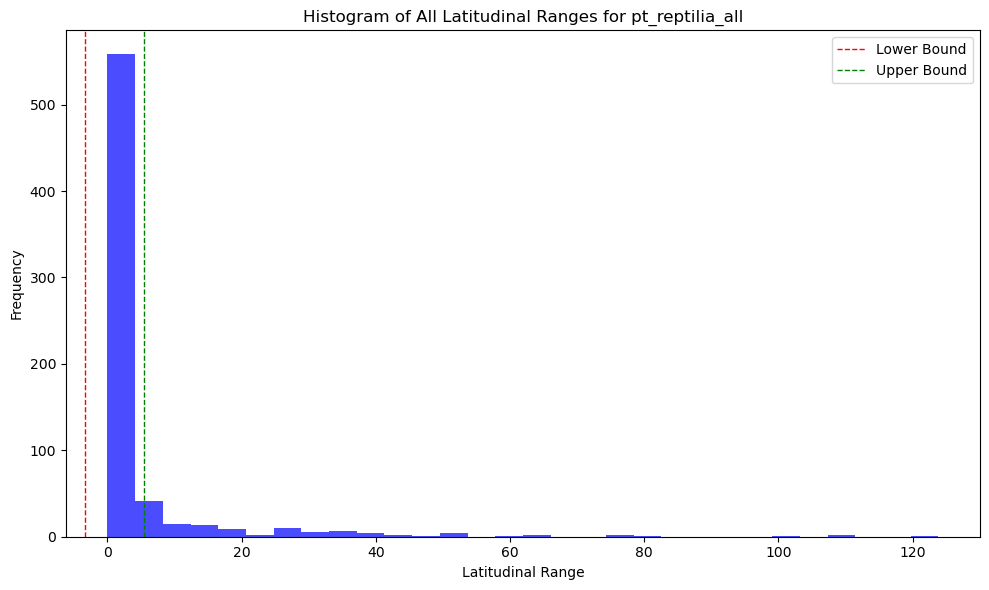

In [121]:
# Plot histogram of latitudinal ranges
plt.figure(figsize=(10, 6))
plt.hist(pt_reptilia_all_lat_ranges['range'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of All Latitudinal Ranges for pt_reptilia_all')
plt.xlabel('Latitudinal Range')
plt.ylabel('Frequency')
plt.axvline(lower_bound, color='red', linestyle='dashed', linewidth=1, label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='dashed', linewidth=1, label='Upper Bound')
plt.legend()
plt.savefig('Perm-Trias/pt_data_visualizations/pt_reptilia_all_lat_ranges_histogram.png')
plt.tight_layout()
plt.show()

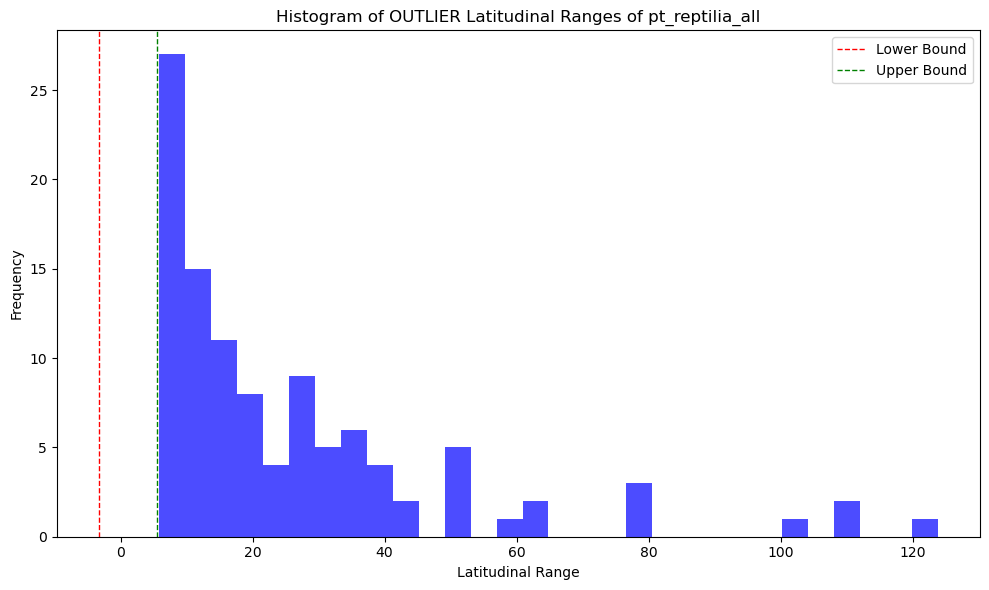

In [120]:
# plot histogram of latitudinal ranges of outliers
outliers_pt_reptilia_all_lat_ranges_df = pt_reptilia_all_lat_ranges[pt_reptilia_all_lat_ranges['range'].isin(outliers_pt_reptilia_all_lat_ranges)]
plt.figure(figsize=(10, 6))
plt.hist(outliers_pt_reptilia_all_lat_ranges_df['range'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of OUTLIER Latitudinal Ranges of pt_reptilia_all')
plt.xlabel('Latitudinal Range')
plt.ylabel('Frequency')
plt.axvline(lower_bound, color='red', linestyle='dashed', linewidth=1, label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='dashed', linewidth=1, label='Upper Bound')
plt.legend()
plt.savefig('Perm-Trias/pt_data_visualizations/outliers_pt_reptilia_all_lat_ranges_histogram.png')
plt.tight_layout()
plt.show()

In [104]:
# Number of genera with latitudinal ranges > 20 degrees
len(pt_reptilia_all_lat_ranges[pt_reptilia_all_lat_ranges['range'] > 20].groupby('genus').size().sort_values(ascending=False))

47

In [107]:
# Number of genera who are outliers in latitudinal range based on IQR method
len(outliers_pt_reptilia_all_lat_ranges_df)

106

In [86]:
# Use 1.5 IQR to find outliers in latitudinal ranges
def find_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    print(f"Outliers in latitudinal ranges for {series}: {outliers}")
    return outliers

pt_reptilia_all_outliers = find_outliers_iqr(pt_reptilia_all_lat_ranges['range'])
pt_reptilia_terr_outliers = find_outliers_iqr(pt_reptilia_terr_lat_ranges['range'])
pt_synapsida_outliers = find_outliers_iqr(pt_synapsida_lat_ranges['range'])
# print("Outliers in latitudinal ranges for pt_reptilia_all:")


Outliers in latitudinal ranges for genus
Abyssomedon            0.00000
Acadiella              0.00000
Acaenasuchus           0.00000
Acallosuchus           0.00000
Acerosodontosaurus     0.00000
                        ...   
Zanclodon              9.85185
Zhongjiania            0.00000
Zupaysaurus            0.00000
new Neotheropoda       0.00000
new Rhynchocephalia    0.00000
Name: range, Length: 682, dtype: float64: genus
Aetosauroides     5.884820
Aetosaurus       19.741860
Angistorhinus     8.357192
Anomoiodon       14.538710
Anshunsaurus      8.228820
                   ...    
Typothorax        7.558767
Utatsusaurus     14.748650
Vancleavea        7.767745
Xinpusaurus       8.228820
Zanclodon         9.851850
Name: range, Length: 106, dtype: float64
Outliers in latitudinal ranges for genus
Abyssomedon            0.00000
Acadiella              0.00000
Acaenasuchus           0.00000
Acallosuchus           0.00000
Acerosodontosaurus     0.00000
                        ...   
Zancl

In [78]:
def lat_ranges_over_20(lat_ranges):
    # Filter for latitudinal ranges greater than 20 degrees and sort by range in descending order
    lat_ranges_over_20 = lat_ranges[lat_ranges['range'] > 20]
    lat_ranges_over_20 = lat_ranges_over_20.sort_values(by='range', ascending=False)
    print(f"Latitudinal ranges over 20 degrees:")
    print(lat_ranges_over_20)
    return lat_ranges_over_20

pt_reptilia_all_lat_ranges_over_20 = lat_ranges_over_20(pt_reptilia_all_lat_ranges)
pt_reptilia_terr_lat_ranges_over_20 = lat_ranges_over_20(pt_reptilia_terr_lat_ranges)
pt_synapsida_lat_ranges_over_20 = lat_ranges_over_20(pt_synapsida_lat_ranges)

Latitudinal ranges over 20 degrees:
                          min        max       range
genus                                               
Proterosuchus      -62.649090  61.217590  123.866680
Plateosaurus       -65.494580  45.574810  111.069390
Garjainia          -60.685250  48.313280  108.998530
Clevosaurus        -49.477130  52.141190  101.618320
Palacrodon         -77.584400   1.353064   78.937464
Teratosaurus       -45.494580  32.593230   78.087810
Coelurosauravus    -50.091960  27.634800   77.726760
Parasuchus         -30.814400  33.314900   64.129300
Hyperodapedon      -52.001180  10.587390   62.588570
Dromomeron         -52.854420   6.088668   58.943088
Tanystropheus       -9.650311  42.706720   52.357031
Psephoderma         -9.650311  41.435560   51.085871
Simosaurus         -14.990220  35.783620   50.773840
Nothosaurus        -12.547470  37.625320   50.172790
Captorhinus        -47.784110   1.521104   49.305214
Placodus            -9.895147  34.449210   44.344357
Proganoche

In [66]:
# Check that all the genera in pt_reptilia_terr_lat_ranges are also in pt_reptilia_all_lat_ranges
pt_reptilia_terr_lat_ranges.index.isin(pt_reptilia_all_lat_ranges.index).all()

True

In [67]:
# LAT BINNING FUNCTION

# Loop through rep_bdnn_dropped and re-name the genuses in the rep_lat_range_20 according to their value in the 'Rotated Lat' column
# which determines which bin they should be in

def lat_binning(df, lat_range_20_list_genus_list):
    df_binned = df.copy()
    for genus in lat_range_20_list_genus_list:
        if genus in df_binned['genus'].values:
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 66.5), 'genus'] = genus + '_Arctic'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 23.5) & (df_binned['Rotated Lat'] < 66.5), 'genus'] = genus + '_Temperate_N'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 0) & (df_binned['Rotated Lat'] < 23.5), 'genus'] = genus + '_Tropical_N'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= -23.5) & (df_binned['Rotated Lat'] < 0), 'genus'] = genus + '_Tropical_S'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= -66.5) & (df_binned['Rotated Lat'] < -23.5), 'genus'] = genus + '_Temperate_S'
            df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] < -66.5), 'genus'] = genus + '_Antarctic'        
    return df_binned

In [ ]:
pt_reptilia_all_binned = lat_binning(pt_reptilia_all_filtered_spellchecked_lats_dropped, pt_reptilia_all_lat_ranges.index.tolist())
pt_reptilia_terr_binned = lat_binning(pt_reptilia_terr_filtered_spellchecked_lats_dropped, pt_reptilia_terr_lat_ranges.index.tolist())
pt_synapsida_binned = lat_binning(pt_synapsida_filtered_spellchecked_lats_dropped, pt_synapsida_lat_ranges.index.tolist())

In [ ]:
# Checking shapes before and after binning, just to make sure we didn't lose any data
# All values should be the same as before binning
pt_reptilia_all_filtered_spellchecked_lats_dropped.shape[0], pt_reptilia_all_binned.shape[0], pt_reptilia_terr_filtered_spellchecked_lats_dropped.shape[0], pt_reptilia_terr_binned.shape[0], pt_synapsida_filtered_spellchecked_lats_dropped.shape[0], pt_synapsida_binned.shape[0]

# Check that the binning worked correctly
# The new dataframes should have more genera than the original ones
print("Genera counts:")
print("Reptilia All Binned:", pt_reptilia_all_binned['genus'].value_counts())
print("Reptilia All Pre-Binning:", pt_reptilia_all_filtered_spellchecked_lats_dropped['genus'].value_counts())
print("Reptilia Terrestrial Binned:", pt_reptilia_terr_binned['genus'].value_counts())
print("Reptilia Terrestrial Pre-Binning:", pt_reptilia_terr_filtered_spellchecked_lats_dropped['genus'].value_counts())
print("Synapsida Binned:", pt_synapsida_binned['genus'].value_counts())
print("Synapsida Pre-Binning:", pt_synapsida_filtered_spellchecked_lats_dropped['genus'].value_counts())


In [ ]:
pd.to_csv(pt_reptilia_all_binned, "Perm-Trias/pt_reptilia_all_lat_binned.csv", index=False)
pd.to_csv(pt_reptilia_terr_binned, "Perm-Trias/pt_reptilia_terr_lat_binned.csv", index=False)
pd.to_csv(pt_synapsida_binned, "Perm-Trias/pt_synapsida_lat_binned.csv", index=False)

# Guadalupian-Ladinian Data

In [30]:
gl_reptilia_terr = pd.read_csv("Perm-Tras/occs_combined/pt_reptilia_all_cleaned.csv")
gl_synapsida = pd.read_csv("Perm-Tras/occs_combined/pt_synapsida_cleaned.csv")

gl_reptilia_terr.head(), gl_synapsida.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Perm-Tras/occs_combined/pt_reptilia_all_cleaned.csv'

In [110]:
# We want to filter for rows that contain only certain values in the "Epoch" column

epochs = ['Guadalupian', 'Lopingian', 'Early Triassic', 'Middle Triassic']

gl_reptilia_terr_epochs = gl_reptilia_terr[gl_reptilia_terr['Epoch'].isin(epochs)]
gl_synapsida_epochs = gl_synapsida[gl_synapsida['Epoch'].isin(epochs)]

gl_reptilia_terr.shape[0], gl_reptilia_terr_epochs.shape[0], gl_synapsida.shape[0], gl_synapsida_epochs.shape[0]    


(3140, 1345, 3184, 2574)

### Latitude Visualizations

In [ ]:
# Visualizing the latitudes
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(gl_reptilia_terr_epochs['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('GL Reptilia Terr - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)    
plt.hist(gl_synapsida_epochs['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('GLSynapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Guad_Ladin/gl_data_visualizations/cleaned_rotated_latitude_histograms.png')
plt.show()

## Saving Non-Lat Binned GT Occs off as PyRate Input .txts

In [111]:
# Filter to columns

cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_reptilia_terr_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

gl_synapsida_epochs_filtered = gl_synapsida_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_synapsida_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_synapsida_epochs_filtered = gl_synapsida_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

In [112]:
gl_reptilia_terr_epochs_filtered.shape[0], gl_synapsida_epochs_filtered.shape[0]

(1345, 2574)

In [113]:
gl_reptilia_terr_epochs_filtered.head(), gl_synapsida_epochs_filtered.head()

(           Species   Status  min_age  max_age
 1056  Rhombopholis  extinct    237.0    246.7
 1057    Langeronyx  extinct    237.0    246.7
 1058  Teratosaurus  extinct    237.0    246.7
 1059   Macrocnemus  extinct    237.0    246.7
 1060   Macrocnemus  extinct    237.0    246.7,
              Species   Status  min_age  max_age
 281  Parabradysaurus  extinct    266.9    276.5
 282  Parabradysaurus  extinct    266.9    276.5
 283       Kamagorgon  extinct    266.9    276.5
 284       Kamagorgon  extinct    266.9    276.5
 285      Microsyodon  extinct    266.9    276.5)

In [114]:
gl_reptilia_terr_epochs_filtered.describe(), gl_synapsida_epochs_filtered.describe()

(           min_age      max_age
 count  1345.000000  1345.000000
 mean    248.402201   254.177386
 std       7.230530     7.931046
 min     237.000000   239.700000
 25%     242.000000   246.700000
 50%     251.200000   251.902000
 75%     251.902000   259.510000
 max     266.900000   274.400000,
            min_age      max_age
 count  2574.000000  2574.000000
 mean    251.945916   257.576842
 std       7.274871     7.716511
 min     237.000000   239.700000
 25%     246.700000   251.902000
 50%     254.140000   259.510000
 75%     254.140000   259.510000
 max     273.010000   276.500000)

In [115]:
gl_reptilia_terr_epochs_filtered.isna().sum(), gl_synapsida_epochs_filtered.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [116]:
# Saving them off as .txt's
gl_reptilia_terr_epochs_filtered.to_csv("Guad-Ladin/gl_reptilia_terr_epochs_filtered.txt", sep="\t", index=False)
gl_synapsida_epochs_filtered.to_csv("Guad-Ladin/gl_synapsida_epochs_filtered.txt", sep="\t", index=False)

## Ages Visualization (Range Plots)

In [ ]:
gl_rep_terr_range_plot = range_plot(gl_reptilia_terr_epochs_filtered, 'gl_reptilia_terr_epochs_filtered', age_max_col = 'max_age', age_min_col = 'min_age')
gl_rep_terr_range_plot.savefig("Guad-Ladin/data_visualizations/gl_reptilia_terr_epochs_filtered_age_range_frequency_plot.png")

gl_synapsida_range_plot = range_plot(gl_synapsida_epochs_filtered, 'gl_synapsida_epochs_filtered', age_max_col = 'max_age', age_min_col = 'min_age')
gl_synapsida_range_plot.savefig("Guad-Ladin/data_visualizations/gl_synapsida_epochs_filtered_age_range_frequency_plot.png")


NameError: name 'range_plot' is not defined

# Time-Series Data (Isotopic)

# Time-Series Data (BRIDGE)